##### What is an AI Agent?

An AI Agent is an LLM that can think, decide, and perform actions instead of only generating text.

Interview:

An AI agent is an LLM-powered system that can reason, plan, use external tools, maintain context, and execute actions to achieve a user's goal.

##### What is Agentic AI?

Agentic AI is an AI system that can autonomously pursue a goal by reasoning, planning, using tools, and adapting based on intermediate results, rather than only generating a single response.

Interview:

Agentic AI refers to systems that combine one or more AI agents with planning, memory, and tool usage to autonomously complete multi-step tasks with minimal human intervention.

##### Agent vs Agentic AI

| AI Agent                      | Agentic AI                    |
| ----------------------------- | ----------------------------- |
| One intelligent agent         | Complete autonomous system    |
| Can use tools                 | Can use many agents and tools |
| Usually solves one task       | Solves complex workflows      |
| Often single-step             | Multi-step reasoning          |
| Example: Travel booking agent | Enterprise travel assistant   |


##### Why Multi-agent architectur?

A single agent can perform the entire workflow, but as the task becomes more complex, it has to manage planning, decision-making, tool usage, and execution in one place. This increases prompt complexity and can make reasoning less reliable as more context needs to be considered. In contrast, a multi-agent architecture follows the principle of separation of concerns. Each agent is responsible for a specific task, such as inventory checking, vendor selection, or order placement. This makes the system more modular, easier to maintain, test, and extend. A supervisor agent coordinates the workflow by deciding which specialized agent should execute next based on the current state. If requirements change, such as adding a new vendor or approval policy, we can update a single agent without affecting the rest of the system.

#### We are building an multi agent which will do reasearch on specific topic and generate the report.

*   Project setup
*   LLM and tools
*   Research Agent
*   Writer Agent
*   Reviewer Agent
*   Export Agent (PDF)
*   Supervisor Agent
*   LangGraph orchestration
*   Streaming execution
*   Final polishing and deployment

In [ ]:
# Config

import os
from dotenv import load_dotenv
load_dotenv()

class Config:

    MODEL = "openai/gpt-oss-120b"
    MODEL2 = "llama-3.3-70b-versatile"

    GROQ_API_KEY = os.getenv("GROQ_API_KEY")


In [2]:
##llm
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=Config.GROQ_API_KEY

class LLM:
    def __init__(self):
        self.model = ChatGroq(model=Config.MODEL)
        self.model2 = ChatGroq(model=Config.MODEL2)

    def get_model(self):
        return self.model

    def get_mode2(self):
        return self.model2

d:\python\AI\pynb\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
d:\python\AI\pynb\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [3]:
llm = LLM()
llm.get_model().invoke("What is python?")

AIMessage(content='**Python Overview**\n====================\n\nPython is a:\n\n* **High-level programming language**: Easy to read and write, with a focus on code readability.\n* **Interpreted language**: Code is executed line by line, without the need for compilation.\n* **General-purpose language**: Can be used for a wide range of applications, including web development, data analysis, artificial intelligence, and more.\n\n**Key Features of Python**\n-------------------------\n\n* **Easy to learn**: Simple syntax and concise code make it a great language for beginners.\n* **Large community**: Active and supportive community, with many libraries, frameworks, and resources available.\n* **Cross-platform**: Can run on multiple operating systems, including Windows, macOS, and Linux.\n* **Extensive libraries**: Includes a wide range of libraries and modules for tasks such as data analysis, web development, and more.\n\n**Common Use Cases for Python**\n------------------------------\n\n* 

In [4]:
# Tavily tool
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
from langchain_tavily import TavilySearch

def get_tavily_tool():

    return TavilySearch(max_results=5)

In [5]:
get_tavily_tool().invoke("Latest new on tamil politics")

{'query': 'Latest new on tamil politics',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ndtv.com/topic/tamil-nadu-politics',
   'title': 'Latest News, Photos, Videos on Tamil Nadu Politics',
   'content': "*   Image 4: img  Sharad Pawar Has An Old 'Two Plus Two' Bargain For Delhi. *   Image 5: img  Can You Stop Boys And Girls From Eloping: Supreme Court On POCSO Misuse. *   Image 6: img  Ahead Of Rath Yatra, Bengal Announces Rs 5 Lakh Aid To 60 Committees. *   Image 7: img  Chhattisgarh Engineer Kills Girlfriend In Gurugram, Jumps In Front Of A Train. *   Image 9: img  IIT Madras, Education Ministry Host National Workshop On Student Wellness. *   Image 10: img  KEA Recruitment 2026: Apply Online For 4,723 Government Vacancies In Karnataka. *   Image 11: img  Government Launches Free AI Course, Here's How To Apply. *   Image 12: img  UGC NET 2026 Cutoff When? *   Image 13: img  NEET UG Re-Test 2026 Result This Week? # Tamil Nadu Politics

In [6]:
# Wkki tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

def get_wiki_tool():

    tries = 0
    while tries < 10:
        
        try:
            api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
            wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki, name="wikipeedia_search", description="Search Wikipedia for information")
            return wiki
        except Exception as e:
            tries += 1
            print(f"Attempt {tries} failed: {e}")
        

    raise RuntimeError("Failed to create Wikipedia tool after 3 attempts.")

In [7]:
# Arxive tool

from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

#Arxiv  tool - API to search research papers
def get_arxiv_tool():
    api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
    arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv papers")
    return arxiv

In [8]:
get_arxiv_tool().invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [9]:
class ToolRegistry:

    @staticmethod
    def research_tools():

        return [
            get_tavily_tool(),
            #get_wiki_tool(),
            get_arxiv_tool()
        ]

In [10]:
#ToolRegistry.research_tools()

#### Research Agent

               User Query
                    │
                    ▼
            Research Agent
                    │
        ┌───────────┴───────────┐
        ▼                       ▼
      LLM                  Research Tools
                                │
                ┌───────────────┼───────────────┐
                ▼               ▼               ▼
             Tavily        Wikipedia        Arxiv
                                │
                                ▼
                      Collected Information
                                │
                                ▼
                    Structured Research Result

In [11]:
## Base Agent
from abc import ABC, abstractmethod

class AgentBase(ABC):

    @abstractmethod
    def run(self, query:str):
        """Execute the agent."""
        pass

In [12]:
#Instead of returning plain text from the Research Agent, 
# we'll define a structured output model using Pydantic.

from pydantic import BaseModel, Field
from typing import Literal

# For Researcher agent
class Source(BaseModel):
    title: str
    url: str
    summary: str | None = None

class ResearchResult(BaseModel):
    topic: str
    summary: str
    sources: list[Source] = Field(default_factory=list)
    agent: str = 'researcher'

# For writer agent
class Report(BaseModel):
    title: str
    markdown: str
    agent: str = 'writer'

# For reviwer agent
class ReviewedReport(BaseModel):
    title: str
    markdown: str
    review_notes: list[str]
    agent: str = 'reviewer'

# For Export agent
class PDFResult(BaseModel):
    file_name: str
    file_path: str
    agent: str = 'txt'

# For Supervisor
class RouteDecision(BaseModel):

    privious_agent: Literal[
        "researcher",
        "writer",
        "reviewer",
        "txt"
    ] | None = None
    
    next_agent: Literal[
        "researcher",
        "writer",
        "reviewer",
        "txt",
        "end"
    ]

    reason: str
    agent: str = 'supervisor'

In [13]:
#Prompts

research_agent_promt = """
You are a senior research analyst.

Your task is to gather information using the available tools.

Requirements:

- Search multiple sources.
- Remove duplicate information.
- Prefer authoritative sources.
- Produce concise research notes.
- Never invent facts.
- Include references.
- Give summary in two lines

Do NOT write a final report.

Return ONLY valid JSON in this format:

{
  "topic": "...",
  "summary": "...",
  "key_points": [
    ...
  ],
  "sources": [
    {
      "title": "...",
      "url": "...",
      "summary": "..."
    }
  ]
}
"""

writer_agent_prompt = """
You are a senior technical writer.

Your task is to transform research notes into a professional report.

Requirements:

- Use Markdown.
- Create clear headings.
- Add an Introduction.
- Explain each key point.
- End with a Conclusion.
- Add a References section.

Do not invent information.
Use only the provided research.
"""

reviewer_agent_prompt = """
You are a senior technical reviewer.

Your job is NOT to rewrite everything.

Instead,

Improve grammar.

Improve readability.

Remove repetition.

Ensure headings are logical.

Ensure references exist.

Do not invent facts.

Return the improved markdown.
"""

supervisor_agent_promt = """
You are the supervisor of a multi-agent research system.

Available agents:

1. researcher
   - Collects information using search tools.

2. writer
   - Writes reports from research.

3. reviewer
   - Reviews and improves reports.

4. txt
   - Generates txt documents.

Rules:

- Decide ONLY next agent.
- Check the current state, if True and move to next state else retry the current state
  research -> writer -> reviewer -> txt
- Never perform the work yourself.
- If the task is complete, return end.
"""

In [14]:
# Our Research agent
from langchain.agents import create_agent
import json
#from langgraph.prebuilt import create_react_agent

class ResearchAgent(AgentBase):

    def __init__(self):

        self.agent = create_agent(
            model=LLM().get_model(),
            tools=ToolRegistry.research_tools(),
            system_prompt=research_agent_promt
        )

    def run(self, query:str):

        result = self.agent.invoke(
            {
                "messages": [
                            ("user",
                            query)
                        ]
            }
        )

        data = json.loads(result["messages"][-1].content)

        research_data = ResearchResult.model_validate(data)
        return research_data


In [16]:
#For testing
research_result = ResearchAgent().run("Do research on Langgraph")


In [17]:
# Writter agent

from langchain.agents import create_agent

class WriterAgent(AgentBase):

    def __init__(self):
        self.agent = create_agent(
            model=LLM().get_mode2(),# using 
            tools=[],
            system_prompt=writer_agent_prompt,
            response_format=Report
        )
    
    def run(self, research):

        response = self.agent.invoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": f"""
                        Write a professional report using the following research.
                        {research.model_dump_json(indent=2)}
                        """
                    }
                ]
            }
        ) 

        return response["structured_response"]

In [18]:
writer_report = WriterAgent().run(research=research_result)

In [19]:
# Reviewer agent

from langchain.agents import create_agent

class ReviewerAgent(AgentBase):

    def __init__(self):
        self.agent = create_agent(
            model=LLM().get_model(),
            tools=[],
            system_prompt=reviewer_agent_prompt,
            response_format=ReviewedReport
        )

    def run(self, report:str):
        response = self.agent.invoke(
            {
                "messages":[
                    {
                        "role": "user",
                        "content":report.model_dump_json(indent=2)
                    }
                ]
            }
        )

        return response["structured_response"]

In [20]:
reviewer_report = ReviewerAgent().run(report=writer_report)

In [21]:
import os
BASE_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
PARENT_DIR = os.path.dirname(BASE_DIR)
AGENT_WRITE_DIR = os.path.join(PARENT_DIR, "data", "agent_write")

In [22]:
# Export agent
from pathlib import Path
from datetime import datetime


class TxtService:

    def generate(self,
        report: ReviewedReport
    ) -> PDFResult:

        output_dir = Path(AGENT_WRITE_DIR)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        txt_doc_name = f"research_report_{timestamp}.txt"
        output_doc = os.path.join(AGENT_WRITE_DIR, txt_doc_name)

        with open(output_doc, "w", encoding="utf-8") as file:
            file.write(report.markdown)
        print(f"{output_doc} wrote...")

        return PDFResult(
            file_name=txt_doc_name,
            file_path=output_doc
        )

In [ ]:
#TxtService().generate(report=reviewer_report)

#### Supervisor agent

                                    User
                                     │
                                     ▼
                              Supervisor Agent
                                     │
                     ┌───────────────┼──────────────────┐
                     ▼               ▼                  ▼
              Research Agent   Writer Agent    Reviewer Agent
                                                        │
                                                        ▼
                                                 PDF Service

In [23]:
from typing import TypedDict

class GraphState(TypedDict):

    query: str
    research: ResearchResult | None
    report: Report | None
    reviewed_report: ReviewedReport | None
    txt: PDFResult | None
    next_node: RouteDecision | None

In [24]:
from langchain.agents import create_agent

class SupervisorAgent:

    def __init__(self):

        self.agent = create_agent(
            model=LLM().get_model(),
            tools=[],
            system_prompt=supervisor_agent_promt,
            response_format=RouteDecision
        )

    def run(self, state):

        content = f"""
                        Current State

                        Query:
                        {state['query']}

                        Research Available:
                        {state.get('research', None) is not None}

                        Report Available:
                        {state.get('report', None) is not None}

                        Reviewed Report Available:
                        {state.get('reviewed_report', None) is not None}

                        PDF Available:
                        {state.get('txt', None) is not None}
                        """
        print(content)
        response = self.agent.invoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": content
                    }
                ]
            }
        )
       
        print(response["structured_response"])

        return response["structured_response"]

In [25]:
def route(state:GraphState):

    return state["next_node"].next_agent

In [26]:
sup = SupervisorAgent()
state={
    "query":"Do research on langgraph",
    "research":"dddd",
    "report": "dooood",
    "reviewed_report": "gugoionoi",
    "txt":"gggggggg"
    }

sup.run(state=state)


                        Current State

                        Query:
                        Do research on langgraph

                        Research Available:
                        True

                        Report Available:
                        True

                        Reviewed Report Available:
                        True

                        PDF Available:
                        True
                        
privious_agent='txt' next_agent='end' reason='Task is complete' agent='supervisor'


RouteDecision(privious_agent='txt', next_agent='end', reason='Task is complete', agent='supervisor')

In [27]:
# Let's create node which kinda act like a wrapper for each agent
supervisor_agent = SupervisorAgent()
research_agent = ResearchAgent()
writer_agent = WriterAgent()
reviewer_agent = ReviewerAgent()
export_agent = TxtService()

test = 0

def research_node(state:GraphState):
    response = research_agent.run(query=state['query'])
    print(f"research node : {response}")
    return {
        "research": response
    }

def writer_node(state:GraphState):
    response = writer_agent.run(research=state['research'])
    print(f"writer node : {response}")
    return {
        "report": response
    }

def reviewer_node(state:GraphState):
    global test
    if test == 0:
        test += 1
    else:
        response = reviewer_agent.run(report=state['report'])
        print(f"reviwer node : {response}")
        return {
            "reviewed_report" : response
        }

def export_node(state:GraphState):
    response = export_agent.generate(report=state["reviewed_report"])
    print(f"export node : {response}")
    return {
        "txt" : response
    }

def supervisor_node(state:GraphState):
    response = supervisor_agent.run(state=state)
    print(f"supervisor node : {state}")
    return {
        "next_node": response
    }

In [28]:
# Langgraph flow

from langgraph.graph import StateGraph, START, END

builder = StateGraph(GraphState)

In [29]:
builder.add_node("supervisor", supervisor_node)

builder.add_node("researcher", research_node)

builder.add_node("writer", writer_node)

builder.add_node("reviewer", reviewer_node)

builder.add_node("txt", export_node)

In [30]:

builder.add_edge(START, 'supervisor')
builder.add_conditional_edges(
    'supervisor',
    route,
    {
        "researcher": "researcher",
        "writer": "writer",
        "reviewer": "reviewer",
        "txt": "txt",
        "end": END,
    },
)

In [31]:
builder.add_edge("researcher", "supervisor")
builder.add_edge("writer", "supervisor")
builder.add_edge("reviewer", "supervisor")
builder.add_edge("txt", "supervisor")

In [32]:
## Compile the graph
graph_builder=builder.compile()

In [33]:
from IPython.display import Image, display

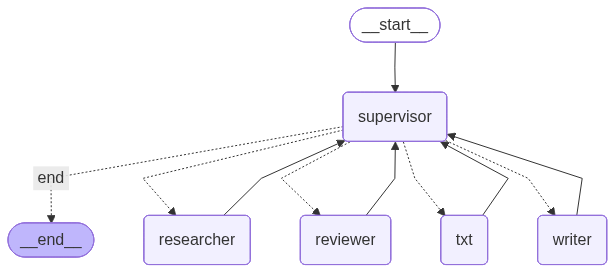

In [34]:
display(Image(graph_builder.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [ ]:
messages=graph_builder.invoke({"query":"Do research on MCP and generate a report in txt file"})


In [ ]:
messages